
# Robustness of FF-SNN MNIST models to RRAM programming error and input noise

This notebook evaluates trained **MNIST FF-SNN** models under two robustness stressors:

1. **RRAM-like weight programming errors** on the crossbar-mapped weight matrices  
2. **Input noise** injected at inference time

It is designed to load the `.pth` artifacts produced by your `mnist_FF_train_v2.py` training script and rebuild the same FF inference path.

## What is included

- loading trained models for **LIF / ALIF / SRM / DynamicSRM**
- baseline accuracy / macro-F1 / spike activity / event-SynOps
- several **RRAM error models**
  - additive Gaussian conductance error
  - multiplicative Gaussian conductance error
  - symmetric weight quantization
  - stuck-at fault injection
  - differential-pair RRAM mismatch
- several **input noise models**
  - additive Gaussian pixel noise
  - salt-and-pepper noise
  - random pixel dropout
- plots and CSV exports of robustness curves

> Edit the `MODEL_PATHS` cell before running the sweeps.


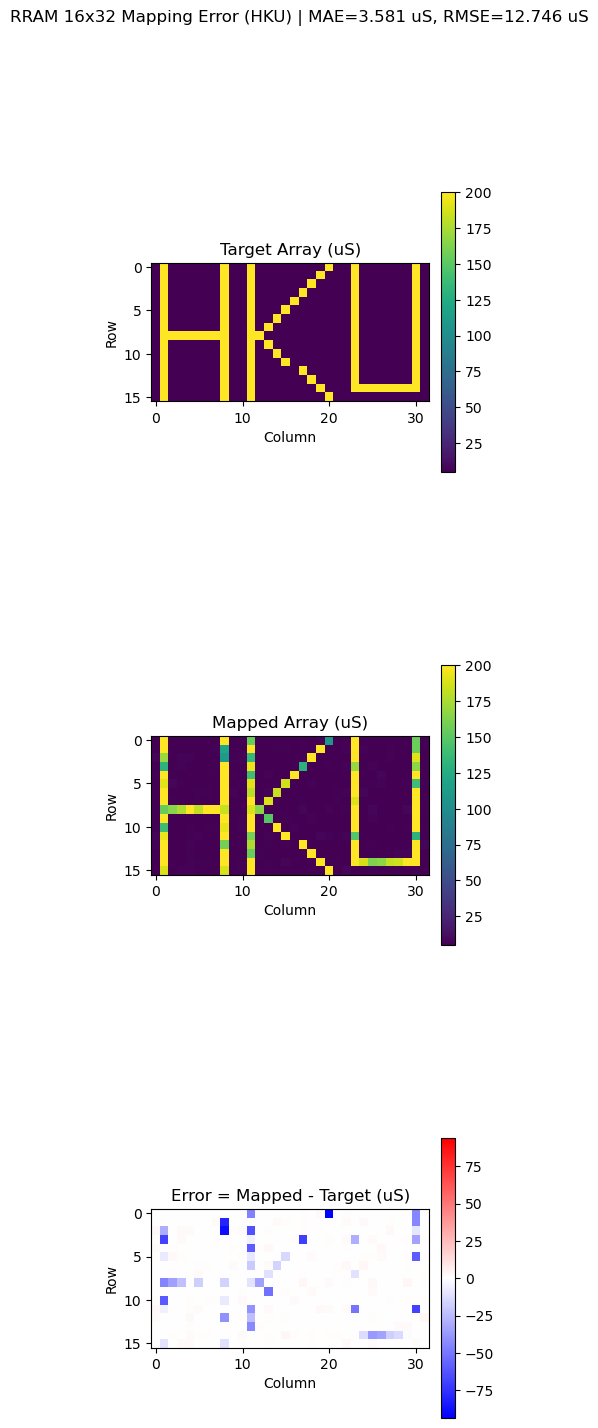

Array shape: (16, 32)
MAE  : 3.5809 uS
RMSE : 12.7463 uS


In [10]:
# Demo: visualize mapping error of a 32x32 RRAM crossbar array
array_h, array_w = 16, 32

# Conductance range and number of programmable levels (example setting)
g_min, g_max = 5e-6, 200e-6
num_levels = 64

# 1) Build target array as a 16x32 "HKU" pattern
# Background uses low conductance, letters use high conductance.
target_array = np.full((array_h, array_w), g_min, dtype=float)

rows = np.arange(array_h)
mid_r = array_h // 2

# ---- H block: cols [1, 9) ----
h_l, h_r = 1, 9
target_array[:, h_l] = g_max
target_array[:, h_r - 1] = g_max
target_array[mid_r, h_l:h_r] = g_max

# ---- K block: cols [11, 21) ----
k_l, k_r = 11, 21
k_mid_r = array_h // 2
k_right = k_r - 1

# Left vertical stroke
target_array[:, k_l] = g_max

# Upper diagonal: from center to top-right
for r in range(0, k_mid_r + 1):
    # r: 0 -> k_mid_r, c: k_right -> k_l+1
    c = int(round(k_right - (k_right - (k_l + 1)) * (r / max(k_mid_r, 1))))
    target_array[r, c] = g_max

# Lower diagonal: from center to bottom-right
for r in range(k_mid_r, array_h):
    # r: k_mid_r -> array_h-1, c: k_l+1 -> k_right
    denom = max(array_h - 1 - k_mid_r, 1)
    c = int(round((k_l + 1) + (k_right - (k_l + 1)) * ((r - k_mid_r) / denom)))
    target_array[r, c] = g_max

# ---- U block: cols [23, 31) ----
u_l, u_r = 23, 31
target_array[:array_h - 2, u_l] = g_max
target_array[:array_h - 2, u_r - 1] = g_max
target_array[array_h - 2, u_l:u_r] = g_max

# 2) Simulate mapping: quantization + programming variation
levels = np.linspace(g_min, g_max, num_levels)
nearest_idx = np.abs(target_array[..., None] - levels[None, None, :]).argmin(axis=-1)
quantized_array = levels[nearest_idx]

# Example write noise model: fixed sigma + conductance-proportional sigma
sigma_fixed = 0.3e-6
sigma_ratio = 0.20  # 3%
noise_std = sigma_fixed + sigma_ratio * quantized_array
mapped_array = quantized_array + np.random.normal(loc=0.0, scale=noise_std, size=quantized_array.shape)
mapped_array = np.clip(mapped_array, g_min, g_max)

# 3) Error map
error_array = mapped_array - target_array
mae = np.mean(np.abs(error_array))
rmse = np.sqrt(np.mean(error_array ** 2))

fig, axes = plt.subplots(3, 1, figsize=(4.2, 15))

im0 = axes[0].imshow(target_array * 1e6, cmap="viridis")
axes[0].set_title("Target Array (uS)")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(mapped_array * 1e6, cmap="viridis")
axes[1].set_title("Mapped Array (uS)")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

err_max = np.max(np.abs(error_array * 1e6))
im2 = axes[2].imshow(error_array * 1e6, cmap="bwr", vmin=-err_max, vmax=err_max)
axes[2].set_title("Error = Mapped - Target (uS)")
axes[2].set_xlabel("Column")
axes[2].set_ylabel("Row")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle(
    f"RRAM {array_h}x{array_w} Mapping Error (HKU) | MAE={mae*1e6:.3f} uS, RMSE={rmse*1e6:.3f} uS",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"Array shape: {target_array.shape}")
print(f"MAE  : {mae*1e6:.4f} uS")
print(f"RMSE : {rmse*1e6:.4f} uS")

In [1]:

import os
import copy
import glob
from pathlib import Path
from typing import Dict, List, Optional, Callable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from spikingjelly.activation_based import functional, neuron, surrogate

SEED = 2026
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda:2



## 1. Configure model paths

Set the `.pth` files for the four trained models.

These should be the `*_best_model.pth` or `*_final_model.pth` artifacts saved by `mnist_FF_train_v2.py`.


In [7]:

# ---- EDIT THESE PATHS ----
MODEL_PATHS = {
    "lif": "/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/lif/MNIST_lif_FF_v2_20260418_162146_best_model.pth",
    "alif": "/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/alif2/MNIST_alif_FF_v2_20260427_005611_best_model.pth",
    "srm": "/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/srm/MNIST_srm_FF_v2_20260418_162541_best_model.pth",
    "dynsrm": "/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/dynsrm2/MNIST_dynsrm_FF_v2_20260427_005708_best_model.pth",
}

# Optional helper: auto-fill the first matching artifact under a root directory.
SEARCH_ROOTS = ["./result", "./result/fintune"]

for model in MODEL_PATHS:
    if MODEL_PATHS[model] is not None:
        continue
    patterns = [f"**/*{model}*best_model.pth", f"**/*{model}*final_model.pth"]
    found = []
    for root in SEARCH_ROOTS:
        for pat in patterns:
            found.extend(glob.glob(os.path.join(root, pat), recursive=True))
    found = sorted(set(found))
    if found:
        MODEL_PATHS[model] = found[-1]

MODEL_PATHS


{'lif': '/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/lif/MNIST_lif_FF_v2_20260418_162146_best_model.pth',
 'alif': '/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/alif2/MNIST_alif_FF_v2_20260427_005611_best_model.pth',
 'srm': '/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/srm/MNIST_srm_FF_v2_20260418_162541_best_model.pth',
 'dynsrm': '/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/dynsrm2/MNIST_dynsrm_FF_v2_20260427_005708_best_model.pth'}

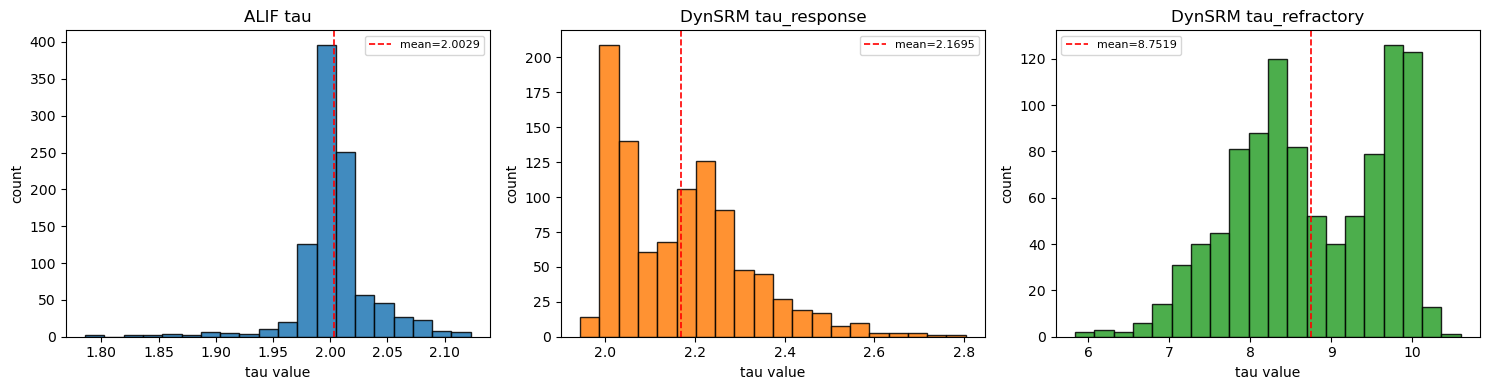

,param,count,mean,std,min,max
0,alif_tau,1000,2.002944,0.034464,1.785845,2.122813
1,dynsrm_tau_response,1000,2.169506,0.148031,1.943543,2.803609
2,dynsrm_tau_refractory,1000,8.751875,0.936672,5.837633,10.597796


ALIF tau-like keys: ['layers.0.neuron.w', 'layers.1.neuron.w']
DynSRM response keys: ['layers.0.neuron.w_tau_response', 'layers.1.neuron.w_tau_response']
DynSRM refractory keys: ['layers.0.neuron.w_tau_refractory', 'layers.1.neuron.w_tau_refractory']


In [8]:
# Distribution plots: ALIF tau, DynSRM tau_response, DynSRM tau_refractory


def _load_state_dict(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    if isinstance(ckpt, dict):
        if "model_state_dict" in ckpt:
            return ckpt["model_state_dict"]
        if "state_dict" in ckpt:
            return ckpt["state_dict"]
    return ckpt


def _to_numpy_1d(x):
    if torch.is_tensor(x):
        return x.detach().cpu().float().reshape(-1).numpy()
    return np.asarray(x, dtype=np.float32).reshape(-1)


def _extract_by_key_substring(sd, substrings):
    vals = []
    for k, v in sd.items():
        key_l = k.lower()
        if any(s in key_l for s in substrings) and torch.is_tensor(v):
            vals.append(_to_numpy_1d(v))
    if len(vals) == 0:
        return np.array([], dtype=np.float32)
    return np.concatenate(vals)


def _extract_alif_tau(sd):
    # 1) If checkpoint already stores explicit tau tensors.
    tau_direct = _extract_by_key_substring(sd, ["tau"])
    if tau_direct.size > 0:
        return tau_direct

    # 2) FF/BP ALIF commonly stores learnable w (not tau): tau = 1 / sigmoid(w).
    w_vals = []
    for k, v in sd.items():
        if torch.is_tensor(v) and (k.endswith(".neuron.w") or k.endswith(".w")):
            w_vals.append(v.detach().cpu().float().reshape(-1))

    if len(w_vals) == 0:
        return np.array([], dtype=np.float32)

    w_cat = torch.cat(w_vals)
    tau = 1.0 / torch.sigmoid(w_cat)
    return tau.numpy()


def _extract_dynsrm_taus(sd):
    # Prefer converting from raw learnable parameters if present.
    w_resp = []
    w_refr = []
    for k, v in sd.items():
        if not torch.is_tensor(v):
            continue
        if "w_tau_response" in k:
            w_resp.append(v.detach().cpu().float().reshape(-1))
        if "w_tau_refractory" in k:
            w_refr.append(v.detach().cpu().float().reshape(-1))

    if len(w_resp) > 0:
        tau_resp = (1.0 + torch.exp(-torch.cat(w_resp))).numpy()
    else:
        tau_resp = _extract_by_key_substring(sd, ["tau_response", "tau_resp", "response_tau"])

    if len(w_refr) > 0:
        tau_refr = (1.0 + torch.exp(-torch.cat(w_refr))).numpy()
    else:
        tau_refr = _extract_by_key_substring(sd, ["tau_refractory", "tau_ref", "refractory_tau"])

    return tau_resp, tau_refr


# Load checkpoints
alif_sd = _load_state_dict(MODEL_PATHS["alif"])
dynsrm_sd = _load_state_dict(MODEL_PATHS["dynsrm"])

# Extract tau distributions
alif_tau = _extract_alif_tau(alif_sd)
dynsrm_tau_response, dynsrm_tau_refractory = _extract_dynsrm_taus(dynsrm_sd)

if alif_tau.size == 0:
    print("[Warn] No ALIF tau data found. Check MODEL_PATHS['alif'] and key names.")
if dynsrm_tau_response.size == 0:
    print("[Warn] No DynSRM tau_response data found.")
if dynsrm_tau_refractory.size == 0:
    print("[Warn] No DynSRM tau_refractory data found.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_items = [
    (alif_tau, "ALIF tau", "tab:blue"),
    (dynsrm_tau_response, "DynSRM tau_response", "tab:orange"),
    (dynsrm_tau_refractory, "DynSRM tau_refractory", "tab:green"),
]

for ax, (arr, title, color) in zip(axes, plot_items):
    if arr.size > 0:
        ax.hist(arr, bins=20, color=color, alpha=0.85, edgecolor="black")
        ax.axvline(arr.mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={arr.mean():.4f}")
        ax.legend(loc="best", fontsize=8)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("tau value")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

stats_df = pd.DataFrame({
    "param": ["alif_tau", "dynsrm_tau_response", "dynsrm_tau_refractory"],
    "count": [alif_tau.size, dynsrm_tau_response.size, dynsrm_tau_refractory.size],
    "mean": [np.nan if alif_tau.size == 0 else alif_tau.mean(),
             np.nan if dynsrm_tau_response.size == 0 else dynsrm_tau_response.mean(),
             np.nan if dynsrm_tau_refractory.size == 0 else dynsrm_tau_refractory.mean()],
    "std": [np.nan if alif_tau.size == 0 else alif_tau.std(),
            np.nan if dynsrm_tau_response.size == 0 else dynsrm_tau_response.std(),
            np.nan if dynsrm_tau_refractory.size == 0 else dynsrm_tau_refractory.std()],
    "min": [np.nan if alif_tau.size == 0 else alif_tau.min(),
            np.nan if dynsrm_tau_response.size == 0 else dynsrm_tau_response.min(),
            np.nan if dynsrm_tau_refractory.size == 0 else dynsrm_tau_refractory.min()],
    "max": [np.nan if alif_tau.size == 0 else alif_tau.max(),
            np.nan if dynsrm_tau_response.size == 0 else dynsrm_tau_response.max(),
            np.nan if dynsrm_tau_refractory.size == 0 else dynsrm_tau_refractory.max()],
})

display(stats_df)

# Debug prints
print("ALIF tau-like keys:", [k for k in alif_sd.keys() if ("tau" in k.lower() or k.endswith(".w") or ".neuron.w" in k)])
print("DynSRM response keys:", [k for k in dynsrm_sd.keys() if ("tau_response" in k.lower() or "tau_resp" in k.lower() or "response_tau" in k.lower() or "w_tau_response" in k)])
print("DynSRM refractory keys:", [k for k in dynsrm_sd.keys() if ("tau_refractory" in k.lower() or "tau_ref" in k.lower() or "refractory_tau" in k.lower() or "w_tau_refractory" in k)])


[lif] path: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/lif/MNIST_lif_FF_v2_20260418_162146_best_model.pth
num state_dict keys: 4
tau-related keys: (none)
tau in ckpt args: {'tau': 3.0, 'tau_response': 2.0, 'tau_refractory': 10.0}

[alif] path: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/alif/MNIST_alif_FF_v2_20260418_162252_best_model.pth
num state_dict keys: 6
tau-related keys: ['layers.0.neuron.w', 'layers.1.neuron.w']
tau in ckpt args: {'tau': 4.0, 'tau_response': 2.0, 'tau_refractory': 10.0}

[srm] path: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/srm/MNIST_srm_FF_v2_20260418_162541_best_model.pth
num state_dict keys: 4
tau-related keys: (none)
tau in ckpt args: {'tau': 2.0, 'tau_response': 3.0, 'tau_refractory': 6.0}

[dynsrm] path: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/best/dynsrm/MNIST_dynsrm_FF_v2_2026

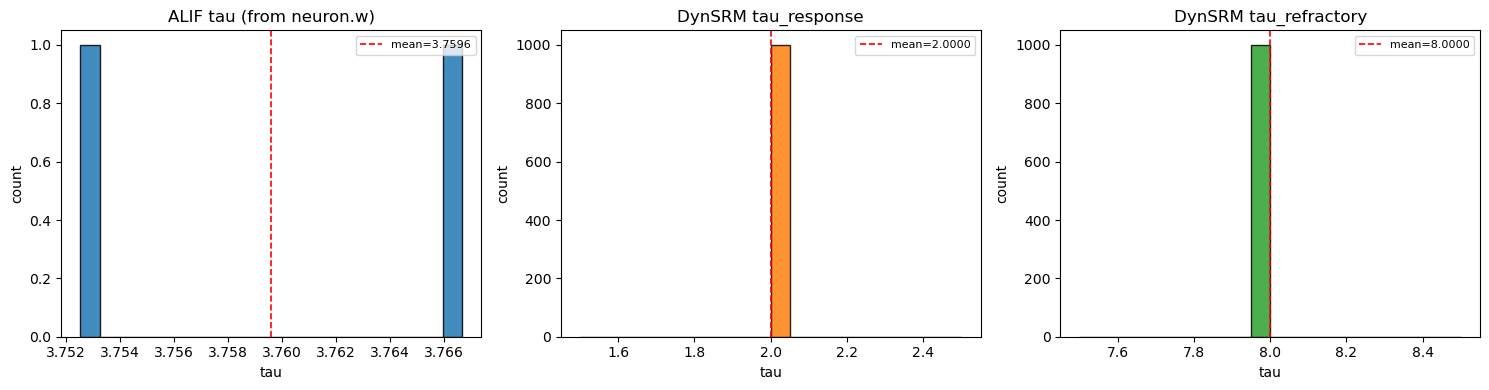

,param,count,mean,std
0,alif_tau,2,3.759599,0.007056
1,dynsrm_tau_response,1000,2.000000,0.000000
2,dynsrm_tau_refractory,1000,8.000000,0.000000



Note: LIF and fixed SRM use fixed tau values from args/config, so they may not appear as learnable tensors in state_dict.


In [32]:
# Check what tau-related info is actually stored in each checkpoint,
# and plot distributions with correct parameter->tau conversion.

def _load_ckpt(path):
    ckpt = torch.load(path, map_location="cpu")
    if not isinstance(ckpt, dict):
        return {"model_state_dict": ckpt, "args": None}
    return ckpt


def _get_state_dict(ckpt):
    if "model_state_dict" in ckpt:
        return ckpt["model_state_dict"]
    if "state_dict" in ckpt:
        return ckpt["state_dict"]
    return ckpt


def _to_np(x):
    return x.detach().cpu().float().reshape(-1).numpy()


# -------- inspect each checkpoint --------
for model_name, model_path in MODEL_PATHS.items():
    ckpt = _load_ckpt(model_path)
    sd = _get_state_dict(ckpt)
    keys = list(sd.keys()) if isinstance(sd, dict) else []
    tau_like = [k for k in keys if "tau" in k.lower() or k.lower().endswith(".w") or "refractory" in k.lower() or "response" in k.lower()]

    print(f"\n[{model_name}] path: {model_path}")
    print(f"num state_dict keys: {len(keys)}")
    print("tau-related keys:", tau_like if len(tau_like) > 0 else "(none)")

    ckpt_args = ckpt.get("args", None)
    if ckpt_args is not None:
        if isinstance(ckpt_args, dict):
            args_dict = ckpt_args
        elif hasattr(ckpt_args, "__dict__"):
            args_dict = vars(ckpt_args)
        else:
            args_dict = None
            print(f"tau in ckpt args: (unsupported args type: {type(ckpt_args)})")

        if args_dict is not None:
            tau_vals = {k: v for k, v in args_dict.items() if "tau" in str(k).lower()}
            print("tau in ckpt args:", tau_vals if len(tau_vals) > 0 else "(none)")

# -------- extract ALIF / DynSRM taus correctly --------
alif_ckpt = _load_ckpt(MODEL_PATHS["alif"])
dynsrm_ckpt = _load_ckpt(MODEL_PATHS["dynsrm"])

alif_sd = _get_state_dict(alif_ckpt)
dynsrm_sd = _get_state_dict(dynsrm_ckpt)

# ALIF (ParametricLIFNode): learnable parameter is w, with 1/tau = sigmoid(w) => tau = 1/sigmoid(w)
alif_w_keys = [k for k in alif_sd.keys() if k.endswith(".neuron.w")]
alif_tau_list = []
for k in alif_w_keys:
    w = alif_sd[k]
    tau = 1.0 / torch.sigmoid(w)
    alif_tau_list.append(_to_np(tau))
alif_tau = np.concatenate(alif_tau_list) if len(alif_tau_list) > 0 else np.array([], dtype=np.float32)

# DynSRM: tau_response = 1 + exp(-w_tau_response), tau_refractory = 1 + exp(-w_tau_refractory)
resp_w_keys = [k for k in dynsrm_sd.keys() if "w_tau_response" in k]
refr_w_keys = [k for k in dynsrm_sd.keys() if "w_tau_refractory" in k]

dyn_tau_resp_list = []
for k in resp_w_keys:
    w = dynsrm_sd[k]
    tau = 1.0 + torch.exp(-w)
    dyn_tau_resp_list.append(_to_np(tau))
dyn_tau_response = np.concatenate(dyn_tau_resp_list) if len(dyn_tau_resp_list) > 0 else np.array([], dtype=np.float32)

dyn_tau_refr_list = []
for k in refr_w_keys:
    w = dynsrm_sd[k]
    tau = 1.0 + torch.exp(-w)
    dyn_tau_refr_list.append(_to_np(tau))
dyn_tau_refractory = np.concatenate(dyn_tau_refr_list) if len(dyn_tau_refr_list) > 0 else np.array([], dtype=np.float32)

# -------- plot 3 histograms --------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_items = [
    (alif_tau, "ALIF tau (from neuron.w)", "tab:blue"),
    (dyn_tau_response, "DynSRM tau_response", "tab:orange"),
    (dyn_tau_refractory, "DynSRM tau_refractory", "tab:green"),
]

for ax, (arr, title, color) in zip(axes, plot_items):
    if arr.size > 0:
        ax.hist(arr, bins=20, color=color, alpha=0.85, edgecolor="black")
        ax.axvline(arr.mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={arr.mean():.4f}")
        ax.legend(loc="best", fontsize=8)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("tau")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

stats_df = pd.DataFrame({
    "param": ["alif_tau", "dynsrm_tau_response", "dynsrm_tau_refractory"],
    "count": [alif_tau.size, dyn_tau_response.size, dyn_tau_refractory.size],
    "mean": [np.nan if alif_tau.size == 0 else alif_tau.mean(),
             np.nan if dyn_tau_response.size == 0 else dyn_tau_response.mean(),
             np.nan if dyn_tau_refractory.size == 0 else dyn_tau_refractory.mean()],
    "std": [np.nan if alif_tau.size == 0 else alif_tau.std(),
            np.nan if dyn_tau_response.size == 0 else dyn_tau_response.std(),
            np.nan if dyn_tau_refractory.size == 0 else dyn_tau_refractory.std()],
})
display(stats_df)

print("\nNote: LIF and fixed SRM use fixed tau values from args/config, so they may not appear as learnable tensors in state_dict.")


## 2. Rebuild the same FF-SNN inference path as training

This follows the same structure as `mnist_FF_train_v2.py`:

- rebuild the net from `args` and `dims` saved in the model artifact
- use the same neuron family and parameters
- use the same **label overlay**
- use the same repeated-static input over `T` steps
- use the same goodness-based prediction over all 10 labels


In [21]:

NUM_CLASSES = 10

def superimpose_label(x: torch.Tensor, y, num_classes: int = 10, label_scale: float = 1.0):
    x = x.clone()
    B = x.size(0)
    if isinstance(y, int):
        y = torch.full((B,), y, device=x.device, dtype=torch.long)
    else:
        y = y.to(x.device, dtype=torch.long).view(-1)
    x[:, :num_classes] = 0.0
    vmax = x.max(dim=1, keepdim=True).values + 1e-6
    x[torch.arange(B, device=x.device), y.clamp(0, num_classes - 1)] = vmax[:, 0] * float(label_scale)
    return x

def repeat_static_input(x: torch.Tensor, T: int, gain: float = 1.0):
    return (x * float(gain)).unsqueeze(0).repeat(T, 1, 1)

def goodness(h: torch.Tensor):
    return h.pow(2).mean(dim=1)

def update_confusion_matrix(confusion: torch.Tensor, pred: torch.Tensor, target: torch.Tensor):
    indices = target * NUM_CLASSES + pred
    counts = torch.bincount(indices, minlength=NUM_CLASSES * NUM_CLASSES)
    confusion += counts.reshape(NUM_CLASSES, NUM_CLASSES)

def macro_classification_metrics(confusion: torch.Tensor):
    confusion = confusion.to(torch.float64)
    tp = confusion.diag()
    predicted = confusion.sum(dim=0)
    actual = confusion.sum(dim=1)
    precision = torch.where(predicted > 0, tp / predicted, torch.zeros_like(tp))
    recall = torch.where(actual > 0, tp / actual, torch.zeros_like(tp))
    denom = precision + recall
    f1 = torch.where(denom > 0, 2.0 * precision * recall / denom, torch.zeros_like(tp))
    return {
        "macro_precision": float(precision.mean().item()),
        "macro_recall": float(recall.mean().item()),
        "macro_f1": float(f1.mean().item()),
    }

def init_activity_summary(num_layers: int):
    return {
        "layers": [{
            "spike_count": 0.0,
            "num_elements": 0.0,
            "input_nonzero_count": 0.0,
            "input_num_elements": 0.0,
            "dense_synops": 0.0,
            "event_synops": 0.0,
        } for _ in range(num_layers)],
        "total_spike_count": 0.0,
        "total_num_elements": 0.0,
        "total_dense_synops": 0.0,
        "total_event_synops": 0.0,
    }

def record_layer_activity(summary, layer_idx: int, x_seq: torch.Tensor, spk_seq: torch.Tensor, out_features: int):
    layer_summary = summary["layers"][layer_idx]
    input_nonzero_count = float(x_seq.ne(0).sum().item())
    input_num_elements = float(x_seq.numel())
    spike_count = float(spk_seq.sum().item())
    num_elements = float(spk_seq.numel())
    dense_synops = float(x_seq.shape[0] * x_seq.shape[1] * x_seq.shape[2] * out_features)
    event_synops = input_nonzero_count * float(out_features)
    layer_summary["spike_count"] += spike_count
    layer_summary["num_elements"] += num_elements
    layer_summary["input_nonzero_count"] += input_nonzero_count
    layer_summary["input_num_elements"] += input_num_elements
    layer_summary["dense_synops"] += dense_synops
    layer_summary["event_synops"] += event_synops
    summary["total_spike_count"] += spike_count
    summary["total_num_elements"] += num_elements
    summary["total_dense_synops"] += dense_synops
    summary["total_event_synops"] += event_synops

def merge_activity_summaries(dst, src):
    for dst_layer, src_layer in zip(dst["layers"], src["layers"]):
        for key in ("spike_count", "num_elements", "input_nonzero_count", "input_num_elements", "dense_synops", "event_synops"):
            dst_layer[key] += src_layer[key]
    for key in ("total_spike_count", "total_num_elements", "total_dense_synops", "total_event_synops"):
        dst[key] += src[key]

def activity_summary_to_metrics(summary):
    total_spike_count = float(summary["total_spike_count"])
    total_num_elements = float(summary["total_num_elements"])
    total_dense_synops = float(summary["total_dense_synops"])
    total_event_synops = float(summary["total_event_synops"])
    out = {
        "total_spikes": total_spike_count,
        "global_spike_rate": total_spike_count / max(total_num_elements, 1.0),
        "dense_synops": total_dense_synops,
        "event_synops": total_event_synops,
        "energy_proxy_synops": total_event_synops,
        "event_to_dense_ratio": total_event_synops / max(total_dense_synops, 1.0),
    }
    for i, layer_summary in enumerate(summary["layers"]):
        out[f"layer_{i}_spike_rate"] = float(layer_summary["spike_count"]) / max(float(layer_summary["num_elements"]), 1.0)
        out[f"layer_{i}_event_synops"] = float(layer_summary["event_synops"])
    return out

def make_neuron_factory(saved_args: dict, out_features: Optional[int] = None):
    model = saved_args["model"]
    common = dict(
        surrogate_function=surrogate.ATan(),
        detach_reset=True,
        v_threshold=float(saved_args.get("v_threshold", saved_args.get("v-threshold", 0.5))),
        v_reset=float(saved_args.get("v_reset", saved_args.get("v-reset", 0.0))),
    )
    if model == "lif":
        return neuron.LIFNode, dict(common, tau=float(saved_args.get("tau", 2.0)))
    elif model == "alif":
        node_cls = getattr(neuron, "ParametricLIFNode", neuron.LIFNode)
        return node_cls, dict(common, init_tau=float(saved_args.get("tau", 2.0)))
    elif model == "srm":
        return neuron.SRMNode, dict(
            common,
            tau_response=float(saved_args.get("tau_response", saved_args.get("tau-response", 2.0))),
            tau_refractory=float(saved_args.get("tau_refractory", saved_args.get("tau-refractory", 10.0))),
        )
    elif model == "dynsrm":
        node_cls = getattr(neuron, "DynamicSRMNode", neuron.SRMNode)
        node_kwargs = dict(
            common,
            init_tau_response=float(saved_args.get("tau_response", saved_args.get("tau-response", 2.0))),
            init_tau_refractory=float(saved_args.get("tau_refractory", saved_args.get("tau-refractory", 10.0))),
        )
        # Important: DynamicSRMNode often lazily creates per-neuron parameters
        # (w_tau_response / w_tau_refractory) on the first forward pass if
        # num_neurons is not provided. Saved checkpoints already contain these
        # parameters, so we must create them at construction time before
        # load_state_dict().
        if out_features is not None:
            node_kwargs["num_neurons"] = int(out_features)
        return node_cls, node_kwargs
    raise ValueError(model)

class FFSpikingLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int, saved_args: dict):
        super().__init__()
        node_cls, node_kwargs = make_neuron_factory(saved_args, out_features=out_features)
        self.fc = nn.Linear(in_features, out_features)
        self.neuron = node_cls(**node_kwargs)
        if hasattr(self.neuron, "step_mode"):
            self.neuron.step_mode = "m"

    def run(self, x_seq: torch.Tensor):
        functional.reset_net(self)
        cur_seq = self.fc(x_seq)
        spk_seq = self.neuron(cur_seq)
        count = spk_seq.sum(dim=0)
        return spk_seq, count

class FFSpikingNet(nn.Module):
    def __init__(self, dims: List[int], saved_args: dict):
        super().__init__()
        self.saved_args = saved_args
        self.layers = nn.ModuleList([
            FFSpikingLayer(dims[i], dims[i + 1], saved_args=saved_args)
            for i in range(len(dims) - 1)
        ])

    @torch.no_grad()
    def layer_goodnesses(self, x_flat: torch.Tensor, y_overlay, activity_summary=None):
        x = superimpose_label(
            x_flat, y_overlay,
            label_scale=float(self.saved_args.get("label_scale", self.saved_args.get("label-scale", 1.0)))
        )
        h_seq = repeat_static_input(
            x,
            T=int(self.saved_args.get("T", 10)),
            gain=float(self.saved_args.get("input_gain", self.saved_args.get("input-gain", 1.0)))
        )
        gs = []
        for layer_idx, layer in enumerate(self.layers):
            spk_seq, h_count = layer.run(h_seq)
            if activity_summary is not None:
                record_layer_activity(activity_summary, layer_idx, h_seq, spk_seq, layer.fc.out_features)
            gs.append(goodness(h_count))
            h_seq = spk_seq.detach()
        return gs

    @torch.no_grad()
    def goodness_per_class(self, x_flat: torch.Tensor, num_classes: int = 10, collect_activity: bool = False):
        activity_summary = init_activity_summary(len(self.layers)) if collect_activity else None
        all_g = []
        for label in range(num_classes):
            g_label = sum(self.layer_goodnesses(x_flat, label, activity_summary=activity_summary))
            all_g.append(g_label.unsqueeze(1))
        all_g = torch.cat(all_g, dim=1)
        if collect_activity:
            return all_g, activity_summary
        return all_g

    @torch.no_grad()
    def predict(self, x_flat: torch.Tensor, collect_activity: bool = False):
        if collect_activity:
            all_g, activity_summary = self.goodness_per_class(x_flat, collect_activity=True)
            return all_g.argmax(dim=1), activity_summary
        return self.goodness_per_class(x_flat).argmax(dim=1)

def load_trained_ff_model(model_path: str, device=DEVICE):
    payload = torch.load(model_path, map_location=device)
    saved_args = dict(payload["args"])
    dims = list(payload["dims"])
    net = FFSpikingNet(dims=dims, saved_args=saved_args).to(device)
    net.load_state_dict(payload["model_state_dict"], strict=True)
    net.eval()
    return net, payload, saved_args, dims


### DynamicSRM loading note

If a saved `dynsrm` checkpoint raises an error like:

`Unexpected key(s) in state_dict: layers.X.neuron.w_tau_response, ...`

the reason is that `DynamicSRMNode` creates its per-neuron parameters lazily unless `num_neurons` is provided.  
This notebook now fixes that by constructing each DynamicSRM layer with `num_neurons=out_features` before loading the checkpoint.


## 3. MNIST test loader

In [22]:

DATA_DIR = "/home/public03/yhxu/spikingjelly/dataset/MNIST"
BATCH_SIZE = 1024
NUM_WORKERS = 4

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),
])

test_dataset = torchvision.datasets.MNIST(root=DATA_DIR, train=False, transform=transform, download=True)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
len(test_dataset)


10000


## 4. Define RRAM weight-error models and input-noise models

These are inference-time perturbations.

### Weight-error models
- `add_gaussian`: additive programming error
- `mul_gaussian`: multiplicative programming error
- `quantize`: finite conductance levels / coarse programming
- `stuck`: stuck-at faults
- `rram_pair`: simple differential-pair conductance mismatch

### Input-noise models
- `gaussian`: additive input noise
- `salt_pepper`: random black/white pixel corruption
- `dropout`: random pixel removal


In [23]:

def quantize_symmetric(w: torch.Tensor, levels: int = 16):
    if levels < 2:
        return torch.zeros_like(w)
    wmax = w.abs().max()
    if float(wmax) == 0.0:
        return w.clone()
    step = 2 * wmax / (levels - 1)
    q = torch.round((w + wmax) / step) * step - wmax
    return q.clamp(-wmax, wmax)

def apply_rram_weight_error(
    net: nn.Module,
    mode: str = "mul_gaussian",
    severity: float = 0.05,
    *,
    quant_levels: int = 16,
    stuck_prob: float = 0.01,
    include_bias: bool = False,
    g_min: float = 0.0,
    g_max: float = 1.0,
    diff_pair_scale: Optional[float] = None,
    seed: int = 0,
):
    torch.manual_seed(seed)
    perturbed = copy.deepcopy(net)
    state = perturbed.state_dict()
    for name, w in list(state.items()):
        is_weight = name.endswith("fc.weight")
        is_bias = name.endswith("fc.bias")
        if not is_weight and not (include_bias and is_bias):
            continue
        if mode == "add_gaussian":
            sigma = severity * max(float(w.abs().max().item()), 1e-8)
            state[name] = w + sigma * torch.randn_like(w)
        elif mode == "mul_gaussian":
            state[name] = w * (1.0 + severity * torch.randn_like(w))
        elif mode == "quantize":
            state[name] = quantize_symmetric(w, levels=quant_levels)
        elif mode == "stuck":
            p = severity if stuck_prob is None else stuck_prob
            mask = torch.rand_like(w) < p
            low, high = (-w.abs().max(), w.abs().max()) if is_weight else (w.min(), w.max())
            stuck_to_high = torch.rand_like(w) < 0.5
            stuck_value = torch.where(stuck_to_high, torch.full_like(w, high), torch.full_like(w, low))
            state[name] = torch.where(mask, stuck_value, w)
        elif mode == "rram_pair":
            scale = diff_pair_scale
            if scale is None:
                w_abs_max = max(float(w.abs().max().item()), 1e-8)
                scale = (g_max - g_min) / w_abs_max
            g_mid = (g_max + g_min) / 2.0
            delta = w * scale / 2.0
            gp = torch.clamp(g_mid + delta, g_min, g_max)
            gn = torch.clamp(g_mid - delta, g_min, g_max)
            gp = torch.clamp(gp * (1.0 + severity * torch.randn_like(gp)), g_min, g_max)
            gn = torch.clamp(gn * (1.0 + severity * torch.randn_like(gn)), g_min, g_max)
            state[name] = (gp - gn) / scale
        else:
            raise ValueError(f"Unknown mode: {mode}")
    perturbed.load_state_dict(state, strict=True)
    perturbed.eval()
    return perturbed

def make_input_noise_fn(mode: Optional[str], severity: float):
    if mode is None or severity <= 0:
        return None
    if mode == "gaussian":
        return lambda x: (x + severity * torch.randn_like(x)).clamp(0.0, 1.0)
    if mode == "salt_pepper":
        def fn(x):
            rnd = torch.rand_like(x)
            x2 = x.clone()
            p = severity / 2.0
            x2[rnd < p] = 0.0
            x2[rnd > 1.0 - p] = 1.0
            return x2
        return fn
    if mode == "dropout":
        return lambda x: x * (torch.rand_like(x) > severity).float()
    raise ValueError(mode)


## 5. Evaluation helper

In [24]:

@torch.no_grad()
def evaluate_model(
    net: FFSpikingNet,
    loader: DataLoader,
    *,
    device=DEVICE,
    input_noise_fn: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
    max_samples: int = 0,
):
    net.eval()
    correct = 0
    total = 0
    confusion = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)
    activity_summary = init_activity_summary(len(net.layers))

    for x, y in loader:
        if max_samples > 0 and total >= max_samples:
            break
        remaining = max_samples - total if max_samples > 0 else y.numel()
        if remaining <= 0:
            break
        if remaining < y.numel():
            x = x[:remaining]
            y = y[:remaining]
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if input_noise_fn is not None:
            x = input_noise_fn(x)
        pred, batch_activity = net.predict(x, collect_activity=True)
        merge_activity_summaries(activity_summary, batch_activity)
        correct += (pred == y).sum().item()
        total += y.numel()
        update_confusion_matrix(confusion, pred.detach().cpu(), y.detach().cpu())

    cls = macro_classification_metrics(confusion)
    metrics = {
        "acc": correct / max(total, 1),
        "macro_precision": cls["macro_precision"],
        "macro_recall": cls["macro_recall"],
        "macro_f1": cls["macro_f1"],
        "samples": total,
        "confusion_matrix": confusion,
    }
    metrics.update(activity_summary_to_metrics(activity_summary))
    return metrics

def baseline_table(model_paths: Dict[str, Optional[str]], max_samples: int = 0):
    rows = []
    models = {}
    for name, path in model_paths.items():
        if path is None or not os.path.exists(path):
            print(f"[skip] missing path for {name}: {path}")
            continue
        net, payload, saved_args, dims = load_trained_ff_model(path, device=DEVICE)
        models[name] = (net, payload, saved_args, dims)
        m = evaluate_model(net, test_loader, max_samples=max_samples)
        rows.append({
            "model": name,
            "path": path,
            "acc": m["acc"],
            "macro_f1": m["macro_f1"],
            "global_spike_rate": m["global_spike_rate"],
            "event_synops": m["event_synops"],
            "event_to_dense_ratio": m["event_to_dense_ratio"],
        })
    df = pd.DataFrame(rows).sort_values(["acc", "macro_f1"], ascending=False)
    return models, df


In [25]:

MODELS, baseline_df = baseline_table(MODEL_PATHS, max_samples=0)
baseline_df


AcceleratorError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## 6. Weight-noise robustness sweep

In [26]:

WEIGHT_NOISE_MODE = "rram_pair"   # "add_gaussian", "mul_gaussian", "quantize", "stuck", "rram_pair"
WEIGHT_SEVERITIES = [0.0, 0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]
QUANT_LEVELS = 16
STUCK_PROB = 0.01
EVAL_MAX_SAMPLES = 0   # 0 = full test set

rows = []
for model_name, item in MODELS.items():
    net, payload, saved_args, dims = item
    for sev in WEIGHT_SEVERITIES:
        net_pert = net if sev == 0 else apply_rram_weight_error(
            net, mode=WEIGHT_NOISE_MODE, severity=sev,
            quant_levels=QUANT_LEVELS, stuck_prob=STUCK_PROB, seed=SEED
        )
        metrics = evaluate_model(net_pert, test_loader, max_samples=EVAL_MAX_SAMPLES)
        rows.append({
            "model": model_name,
            "noise_domain": "weight",
            "noise_mode": WEIGHT_NOISE_MODE,
            "severity": sev,
            "acc": metrics["acc"],
            "macro_f1": metrics["macro_f1"],
            "global_spike_rate": metrics["global_spike_rate"],
            "event_synops": metrics["event_synops"],
            "event_to_dense_ratio": metrics["event_to_dense_ratio"],
        })
weight_df = pd.DataFrame(rows)
weight_df.head()


NameError: name 'MODELS' is not defined

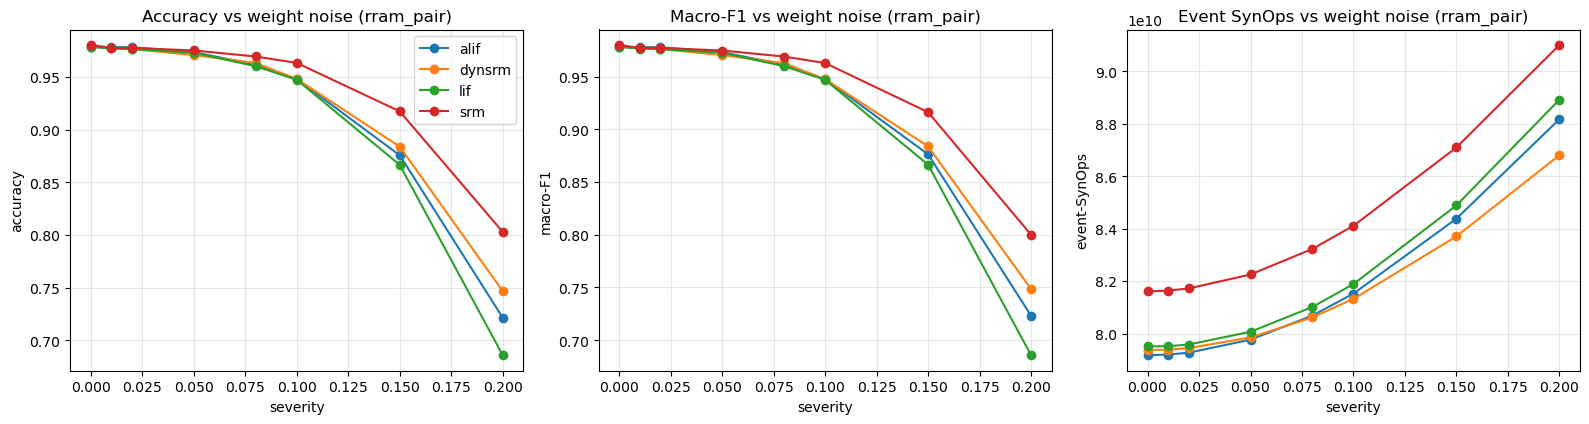

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for model_name, g in weight_df.groupby("model"):
    g = g.sort_values("severity")
    axes[0].plot(g["severity"], g["acc"], marker="o", label=model_name)
    axes[1].plot(g["severity"], g["macro_f1"], marker="o", label=model_name)
    axes[2].plot(g["severity"], g["event_synops"], marker="o", label=model_name)
axes[0].set_title(f"Accuracy vs weight noise ({WEIGHT_NOISE_MODE})")
axes[1].set_title(f"Macro-F1 vs weight noise ({WEIGHT_NOISE_MODE})")
axes[2].set_title(f"Event SynOps vs weight noise ({WEIGHT_NOISE_MODE})")
for ax in axes:
    ax.set_xlabel("severity")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("accuracy")
axes[1].set_ylabel("macro-F1")
axes[2].set_ylabel("event-SynOps")
axes[0].legend()
plt.tight_layout()
plt.show()


## 7. Input-noise robustness sweep

In [10]:

INPUT_NOISE_MODE = "gaussian"    # "gaussian", "salt_pepper", "dropout"
INPUT_SEVERITIES = [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]

rows = []
for model_name, item in MODELS.items():
    net, payload, saved_args, dims = item
    for sev in INPUT_SEVERITIES:
        input_noise_fn = make_input_noise_fn(INPUT_NOISE_MODE, sev)
        metrics = evaluate_model(net, test_loader, input_noise_fn=input_noise_fn, max_samples=EVAL_MAX_SAMPLES)
        rows.append({
            "model": model_name,
            "noise_domain": "input",
            "noise_mode": INPUT_NOISE_MODE,
            "severity": sev,
            "acc": metrics["acc"],
            "macro_f1": metrics["macro_f1"],
            "global_spike_rate": metrics["global_spike_rate"],
            "event_synops": metrics["event_synops"],
            "event_to_dense_ratio": metrics["event_to_dense_ratio"],
        })
input_df = pd.DataFrame(rows)
input_df.head()


,model,noise_domain,noise_mode,severity,acc,macro_f1,global_spike_rate,event_synops,event_to_dense_ratio
0,lif,input,gaussian,0.00,0.9783,0.978153,0.010457,7.950879e+10,0.123845
1,lif,input,gaussian,0.02,0.9770,0.976838,0.008903,2.342268e+11,0.364839
2,lif,input,gaussian,0.05,0.9732,0.972989,0.006878,2.328012e+11,0.362619
3,lif,input,gaussian,0.08,0.9701,0.969893,0.005292,2.315602e+11,0.360686
4,lif,input,gaussian,0.10,0.9630,0.962537,0.004469,2.308509e+11,0.359581


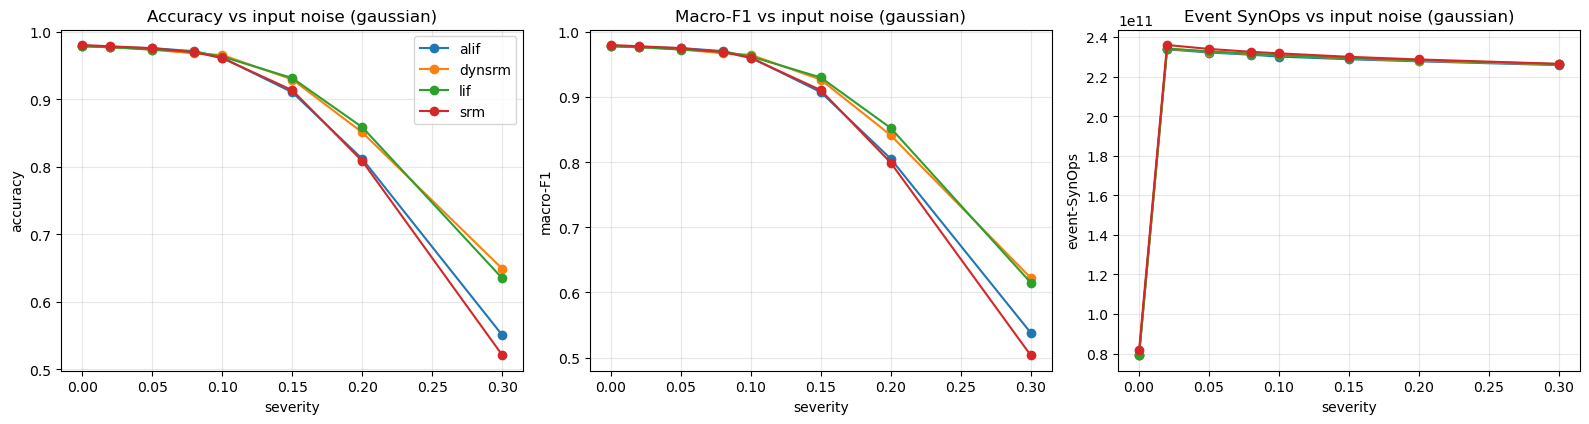

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for model_name, g in input_df.groupby("model"):
    g = g.sort_values("severity")
    axes[0].plot(g["severity"], g["acc"], marker="o", label=model_name)
    axes[1].plot(g["severity"], g["macro_f1"], marker="o", label=model_name)
    axes[2].plot(g["severity"], g["event_synops"], marker="o", label=model_name)
axes[0].set_title(f"Accuracy vs input noise ({INPUT_NOISE_MODE})")
axes[1].set_title(f"Macro-F1 vs input noise ({INPUT_NOISE_MODE})")
axes[2].set_title(f"Event SynOps vs input noise ({INPUT_NOISE_MODE})")
for ax in axes:
    ax.set_xlabel("severity")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("accuracy")
axes[1].set_ylabel("macro-F1")
axes[2].set_ylabel("event-SynOps")
axes[0].legend()
plt.tight_layout()
plt.show()


## 8. Combined noise sweep

In [12]:

COMBINED_WEIGHT_MODE = "rram_pair"
COMBINED_INPUT_MODE = "gaussian"
COMBINED_WEIGHT_SEVERITY = 0.05
COMBINED_INPUT_SEVERITIES = [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]

rows = []
for model_name, item in MODELS.items():
    net, payload, saved_args, dims = item
    net_pert = apply_rram_weight_error(
        net, mode=COMBINED_WEIGHT_MODE, severity=COMBINED_WEIGHT_SEVERITY,
        quant_levels=QUANT_LEVELS, stuck_prob=STUCK_PROB, seed=SEED
    )
    for sev in COMBINED_INPUT_SEVERITIES:
        input_noise_fn = make_input_noise_fn(COMBINED_INPUT_MODE, sev)
        metrics = evaluate_model(net_pert, test_loader, input_noise_fn=input_noise_fn, max_samples=EVAL_MAX_SAMPLES)
        rows.append({
            "model": model_name,
            "weight_mode": COMBINED_WEIGHT_MODE,
            "weight_severity": COMBINED_WEIGHT_SEVERITY,
            "input_mode": COMBINED_INPUT_MODE,
            "input_severity": sev,
            "acc": metrics["acc"],
            "macro_f1": metrics["macro_f1"],
            "global_spike_rate": metrics["global_spike_rate"],
            "event_synops": metrics["event_synops"],
        })
combined_df = pd.DataFrame(rows)
combined_df.head()


,model,weight_mode,weight_severity,input_mode,input_severity,acc,macro_f1,global_spike_rate,event_synops
0,lif,rram_pair,0.05,gaussian,0.00,0.9728,0.972695,0.011830,8.006969e+10
1,lif,rram_pair,0.05,gaussian,0.02,0.9714,0.971263,0.010218,2.347461e+11
2,lif,rram_pair,0.05,gaussian,0.05,0.9689,0.968708,0.008115,2.332655e+11
3,lif,rram_pair,0.05,gaussian,0.08,0.9618,0.961519,0.006447,2.319792e+11
4,lif,rram_pair,0.05,gaussian,0.10,0.9541,0.953610,0.005559,2.312433e+11


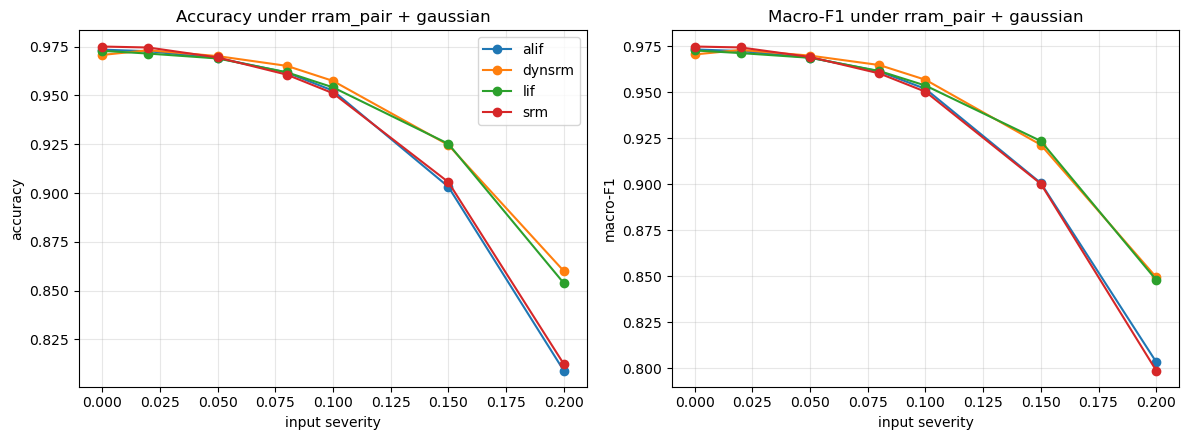

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for model_name, g in combined_df.groupby("model"):
    g = g.sort_values("input_severity")
    axes[0].plot(g["input_severity"], g["acc"], marker="o", label=model_name)
    axes[1].plot(g["input_severity"], g["macro_f1"], marker="o", label=model_name)
axes[0].set_title(f"Accuracy under {COMBINED_WEIGHT_MODE} + {COMBINED_INPUT_MODE}")
axes[1].set_title(f"Macro-F1 under {COMBINED_WEIGHT_MODE} + {COMBINED_INPUT_MODE}")
for ax in axes:
    ax.set_xlabel("input severity")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("accuracy")
axes[1].set_ylabel("macro-F1")
axes[0].legend()
plt.tight_layout()
plt.show()



## 9. Robustness summary tables

These summaries help compare the four neuron types by both clean accuracy and degradation slope.

`relative_acc_drop` and `relative_f1_drop` are measured against each model's clean baseline.


In [ ]:

def attach_clean_baseline(df: pd.DataFrame, severity_col: str = "severity"):
    baseline = (
        df[df[severity_col] == 0]
        .set_index("model")[["acc", "macro_f1"]]
        .rename(columns={"acc": "clean_acc", "macro_f1": "clean_macro_f1"})
    )
    out = df.join(baseline, on="model")
    out["relative_acc_drop"] = (out["clean_acc"] - out["acc"]) / out["clean_acc"].clip(lower=1e-9)
    out["relative_f1_drop"] = (out["clean_macro_f1"] - out["macro_f1"]) / out["clean_macro_f1"].clip(lower=1e-9)
    return out

weight_df2 = attach_clean_baseline(weight_df)
input_df2 = attach_clean_baseline(input_df)

print("Worst-case weight-noise robustness")
display(
    weight_df2.groupby("model")[["acc", "macro_f1", "relative_acc_drop", "relative_f1_drop"]]
    .agg({"acc":"min", "macro_f1":"min", "relative_acc_drop":"max", "relative_f1_drop":"max"})
    .sort_values("acc", ascending=False)
)

print("Worst-case input-noise robustness")
display(
    input_df2.groupby("model")[["acc", "macro_f1", "relative_acc_drop", "relative_f1_drop"]]
    .agg({"acc":"min", "macro_f1":"min", "relative_acc_drop":"max", "relative_f1_drop":"max"})
    .sort_values("acc", ascending=False)
)


## 10. Save the robustness results

In [ ]:

OUT_DIR = "./robustness_results"
os.makedirs(OUT_DIR, exist_ok=True)

baseline_df.to_csv(os.path.join(OUT_DIR, "baseline_metrics.csv"), index=False)
weight_df.to_csv(os.path.join(OUT_DIR, f"weight_noise_{WEIGHT_NOISE_MODE}.csv"), index=False)
input_df.to_csv(os.path.join(OUT_DIR, f"input_noise_{INPUT_NOISE_MODE}.csv"), index=False)
combined_df.to_csv(os.path.join(OUT_DIR, f"combined_{COMBINED_WEIGHT_MODE}_{COMBINED_INPUT_MODE}.csv"), index=False)

print("Saved to", OUT_DIR)



## Notes for interpretation

- If one neuron type keeps **higher accuracy / macro-F1** as weight-noise severity increases, it is more robust to **RRAM programming error**.
- If one neuron type keeps higher performance as input severity increases, it is more robust to **sensor/input corruption**.
- If a model's **event-SynOps** changes sharply under perturbation, the noise is also changing the **inference activity/energy proxy**, not only the prediction.
- `rram_pair` is usually the most physically relevant starting point when you want to mimic a **signed weight stored by differential conductances**.
